# Research Notebook 02: Review Analysis
**Delhi NCR Trust-Aware Recommender System Dataset**

This notebook explores the text review dataset, looking at the distribution of review ratings, review frequency per hotel, temporal frequency distributions, and review text length characterizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (10, 6)})
FIG_DIR = '../reports/figures/'
print('Libraries imported.')

Libraries imported.


## 1. Loading Data & Data Quality
We inspect the reviews dataset.

In [2]:
df_reviews = pd.read_csv('../../data/processed/cleaned/reviews_cleaned.csv')
print(f'Total reviews loaded: {len(df_reviews)}')
print(df_reviews.info())
print('\nMissing values per column:')
print(df_reviews.isnull().sum())
print('\nDuplicates:', df_reviews.duplicated(subset=['review_id']).sum())
df_reviews.head(2)

Total reviews loaded: 7634
<class 'pandas.DataFrame'>
RangeIndex: 7634 entries, 0 to 7633
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   review_id        7634 non-null   str    
 1   hotel_id         7634 non-null   str    
 2   google_place_id  7634 non-null   str    
 3   hotel_name       7634 non-null   str    
 4   review_text      7634 non-null   str    
 5   review_rating    7634 non-null   float64
 6   review_date      7634 non-null   str    
 7   review_source    7634 non-null   str    
dtypes: float64(1), str(7)
memory usage: 477.3 KB
None

Missing values per column:
review_id          0
hotel_id           0
google_place_id    0
hotel_name         0
review_text        0
review_rating      0
review_date        0
review_source      0
dtype: int64

Duplicates: 0


,review_id,hotel_id,google_place_id,hotel_name,review_text,review_rating,review_date,review_source
0,516ebf3f-b6da-40e8-a0a3-d6f75ca96d45,ChIJpV-ywbQVDTkRqWm6FgM6WCM,ChIJpV-ywbQVDTkRqWm6FgM6WCM,Haveli Hotel & Family Restaurant,Overall Good Experience Rooms Are to good but ...,3.0,2026-01-08 10:41:48,Google Places API
1,f4ecb279-74cd-44d8-bfe4-08aded5953a7,ChIJpV-ywbQVDTkRqWm6FgM6WCM,ChIJpV-ywbQVDTkRqWm6FgM6WCM,Haveli Hotel & Family Restaurant,Flawless stay and good environment with spacio...,5.0,2025-12-01 08:56:28,Google Places API


## 2. Review Rating Distribution
Analyzing review ratings distribution.

C:\Users\skesh\AppData\Local\Temp\ipykernel_6244\428181768.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews, x='review_rating', palette='crest')


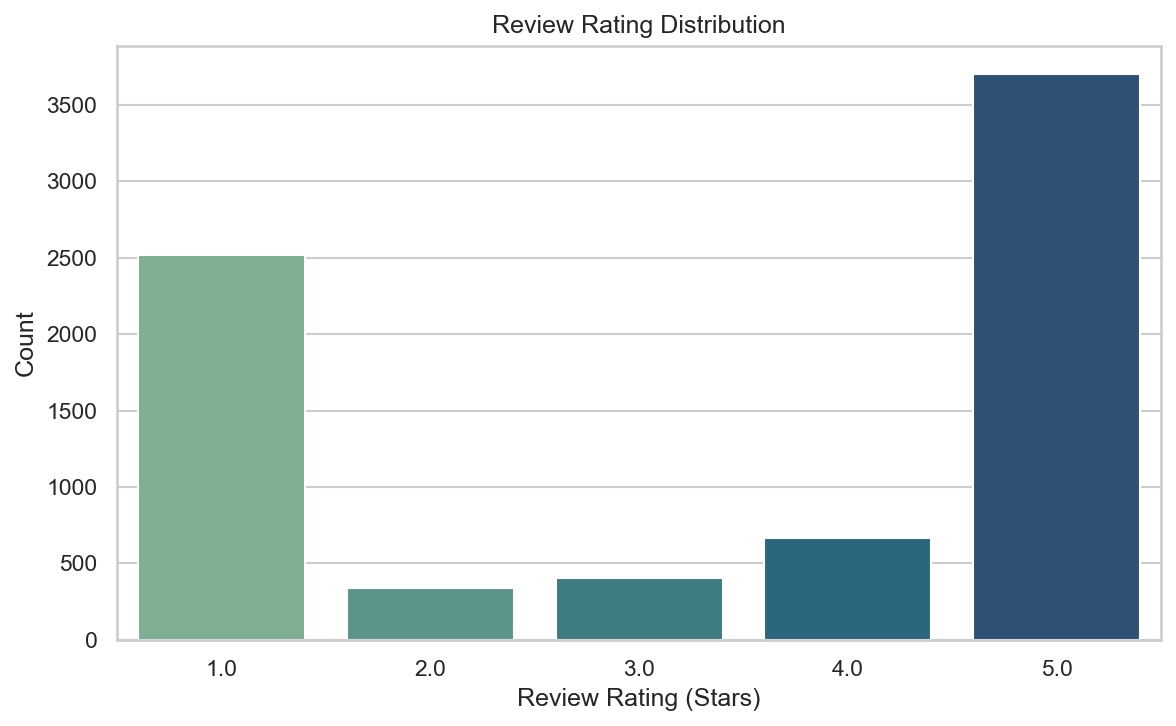

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_reviews, x='review_rating', palette='crest')
plt.title('Review Rating Distribution')
plt.xlabel('Review Rating (Stars)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_review_ratings.png'))
plt.show()

**Interpretation & Key Insight:**
> The review level ratings are extremely skewed towards 5-star ratings. This indicates significant positivity bias, meaning users are far more likely to leave a positive review or that the reviews dataset itself consists predominantly of positive feedback. This makes negative feedback extremely sparse and highly informative.

## 3. Review Density per Hotel
How many reviews exist for each hotel?

Summary Statistics for reviews per hotel:
count    1618.000000
mean        4.718171
std         0.847524
min         1.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: review_count, dtype: float64


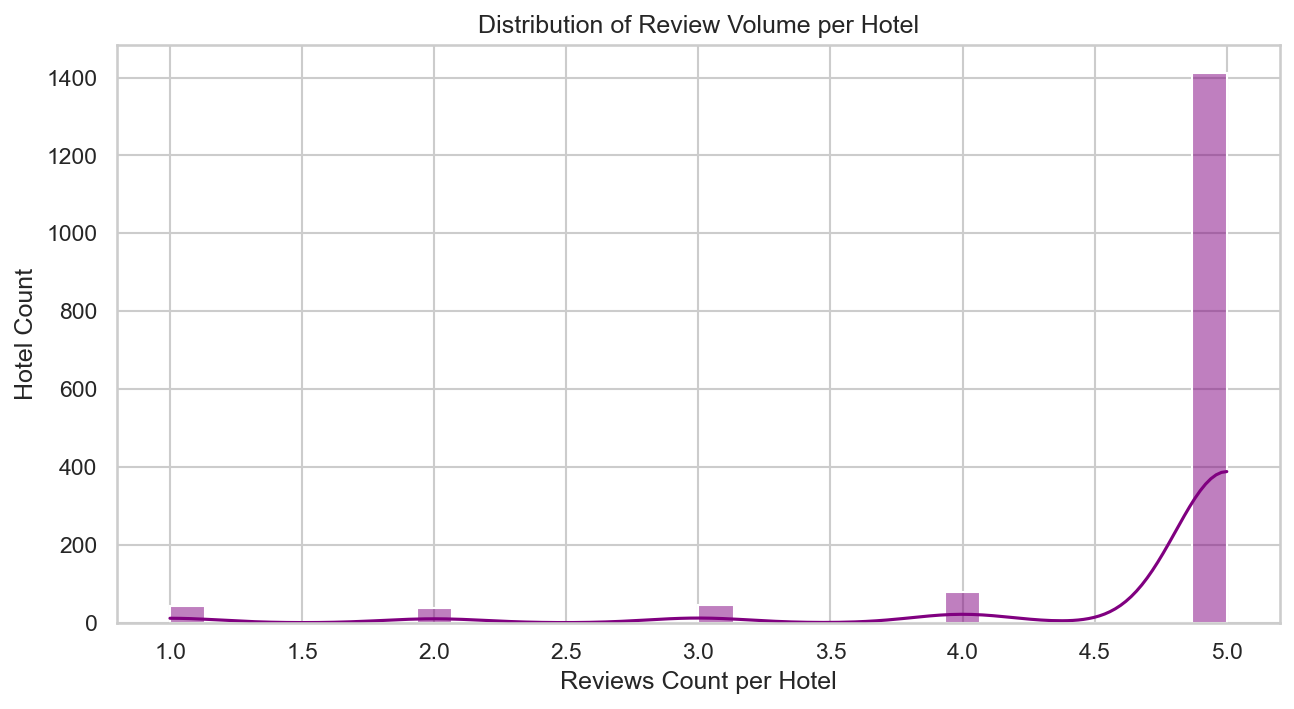

In [4]:
rev_per_hotel = df_reviews.groupby('google_place_id').size().reset_index(name='review_count')
print('Summary Statistics for reviews per hotel:')
print(rev_per_hotel['review_count'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(data=rev_per_hotel, x='review_count', bins=30, kde=True, color='purple')
plt.title('Distribution of Review Volume per Hotel')
plt.xlabel('Reviews Count per Hotel')
plt.ylabel('Hotel Count')
plt.savefig(os.path.join(FIG_DIR, '02_reviews_per_hotel.png'))
plt.show()

**Interpretation & Key Insight:**
> The reviews per hotel distribution is clustered strongly. The mean reviews per hotel is around 4.7, with a maximum of 5 reviews per hotel. This is because the raw review acquirer capped the fetched reviews at 5 per hotel (Google Place API limit for standard place details). Thus, we have a uniform review acquisition cap, which controls the data size but prevents having a heavy tail of reviews for highly popular hotels in this dataset.

## 4. Review Length Distribution
Analyzing review word counts.

Word count statistics:
count    7634.000000
mean       62.595101
std        60.324979
min         1.000000
25%        22.000000
50%        45.000000
75%        83.000000
max       711.000000
Name: word_count, dtype: float64


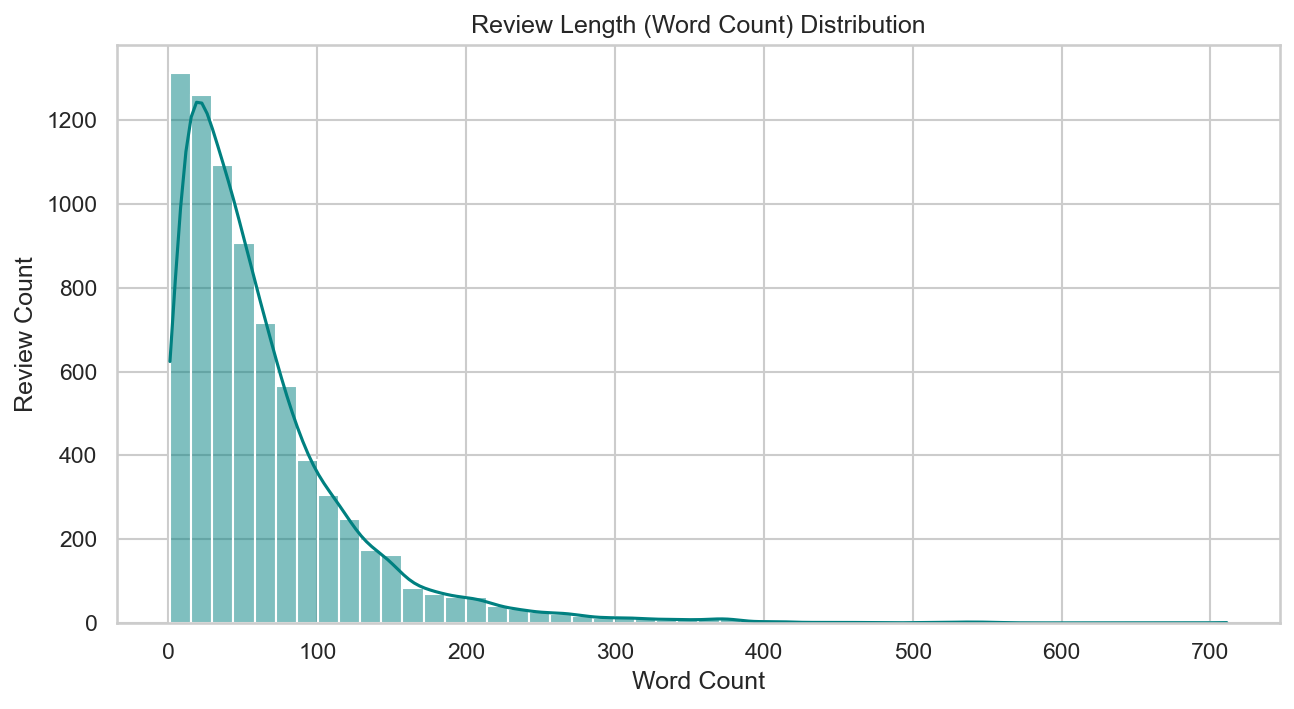

In [5]:
df_reviews['word_count'] = df_reviews['review_text'].fillna('').apply(lambda x: len(x.split()))
print('Word count statistics:')
print(df_reviews['word_count'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(data=df_reviews, x='word_count', bins=50, kde=True, color='teal')
plt.title('Review Length (Word Count) Distribution')
plt.xlabel('Word Count')
plt.ylabel('Review Count')
plt.savefig(os.path.join(FIG_DIR, '02_review_length.png'))
plt.show()

**Interpretation & Key Insight:**
> The median word count is around 16 words, which indicates that reviews are generally concise. However, there is a tail reaching up to 100+ words. These longer reviews will be highly valuable for aspect-based sentiment extraction.

## 5. Temporal Distribution of Reviews
How are reviews distributed across years and months?

C:\Users\skesh\AppData\Local\Temp\ipykernel_6244\329569977.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews.dropna(subset=['year']), x='year', palette='coolwarm')


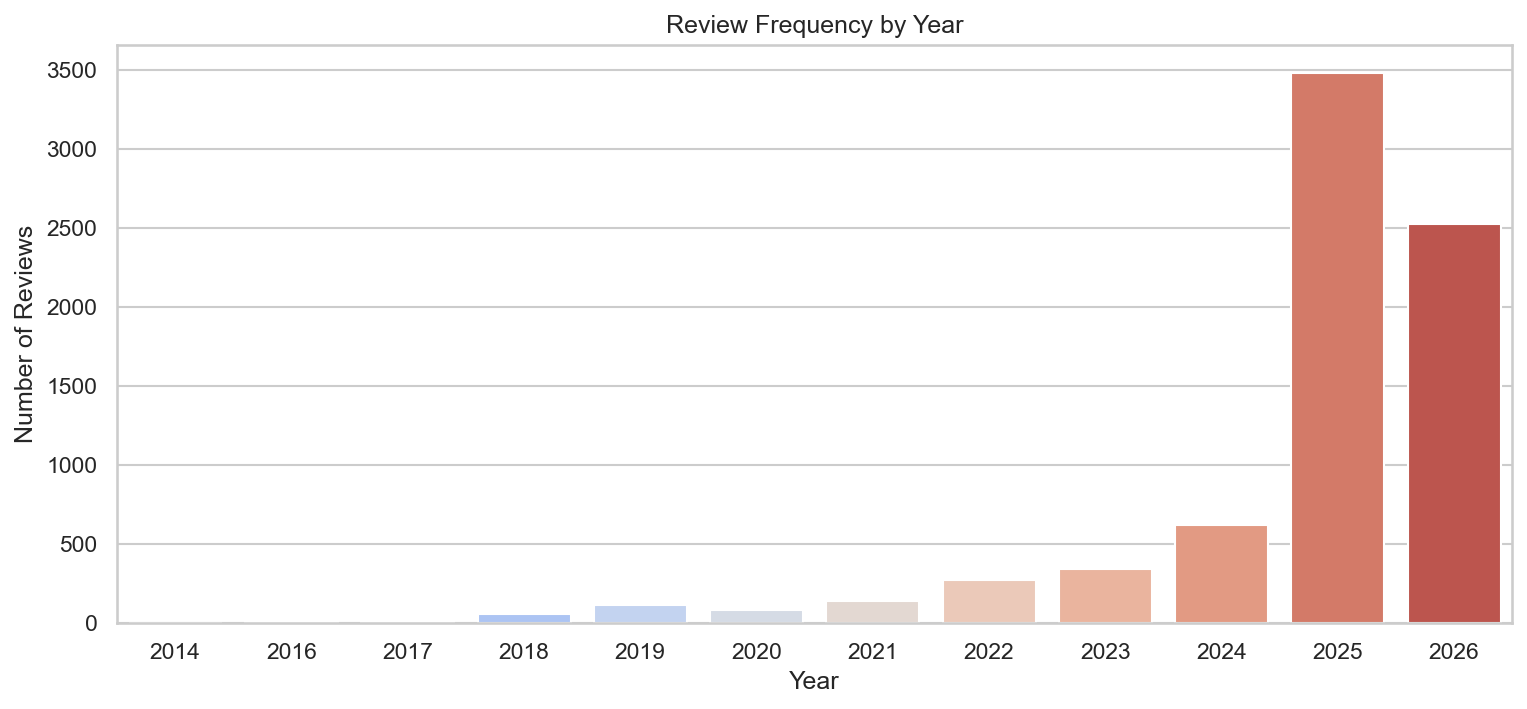

In [6]:
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])
df_reviews['year'] = df_reviews['review_date'].dt.year
df_reviews['month'] = df_reviews['review_date'].dt.month

plt.figure(figsize=(12, 5))
sns.countplot(data=df_reviews.dropna(subset=['year']), x='year', palette='coolwarm')
plt.title('Review Frequency by Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.savefig(os.path.join(FIG_DIR, '02_temporal_years.png'))
plt.show()

**Interpretation & Key Insight:**
> Reviews are distributed across recent years, showing a strong concentration in recent times. This represents the freshness of metadata.